<a href="https://colab.research.google.com/github/vrishank-ramineni/ECON3916---Statistics-Machine-Learning/blob/main/Assignment_3_The_Causal_Architecture.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [21]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import NearestNeighbors

plt.rcParams.update({
    'figure.figsize': (10, 5),
    'axes.spines.top': False,
    'axes.spines.right': False,
    'font.size': 12
})

Sample size        : 250
Observed Mean      : $2.77
Observed Median    : $0.76
Fraction of zeros  : 40%


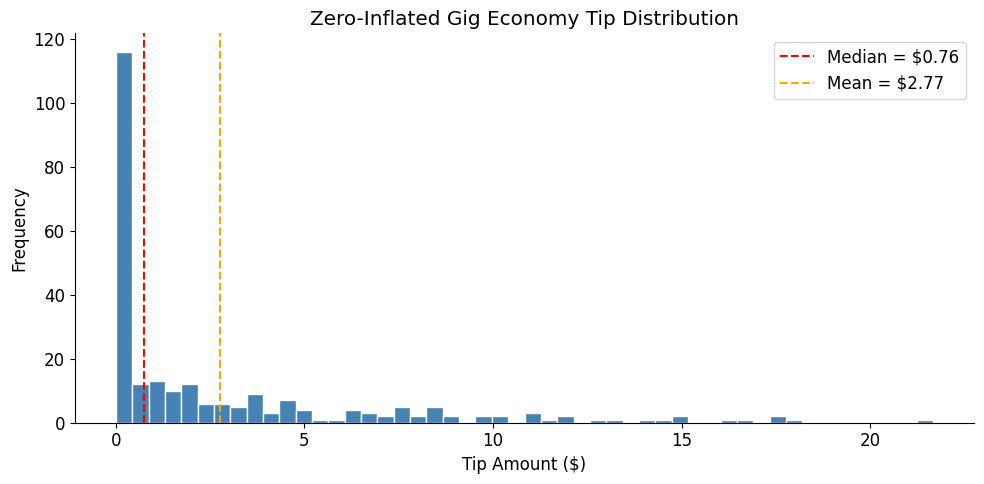

In [22]:
np.random.seed(42)

zeros = np.zeros(100)
tips  = np.random.exponential(scale=5.0, size=150)
driver_tips = np.concatenate([zeros, tips])

observed_median = np.median(driver_tips)
observed_mean   = np.mean(driver_tips)

print(f"Sample size        : {len(driver_tips)}")
print(f"Observed Mean      : ${observed_mean:.2f}")
print(f"Observed Median    : ${observed_median:.2f}")
print(f"Fraction of zeros  : {np.mean(driver_tips == 0):.0%}")

fig, ax = plt.subplots()
ax.hist(driver_tips, bins=50, edgecolor='white', color='steelblue')
ax.axvline(observed_median, color='red', ls='--', label=f'Median = ${observed_median:.2f}')
ax.axvline(observed_mean,   color='orange', ls='--', label=f'Mean = ${observed_mean:.2f}')
ax.set(xlabel='Tip Amount ($)', ylabel='Frequency',
       title='Zero-Inflated Gig Economy Tip Distribution')
ax.legend()
plt.tight_layout()
plt.show()

BOOTSTRAP RESULTS  (B = 10,000)
Observed Sample Median   : $0.7553
Bootstrap Mean of Medians: $0.7665
Bootstrap Std Error      : $0.2758
95% CI (Percentile)      : [$0.2643,  $1.3636]
CI Width                 : $1.0993
Distance below median    : $0.4911
Distance above median    : $0.6082


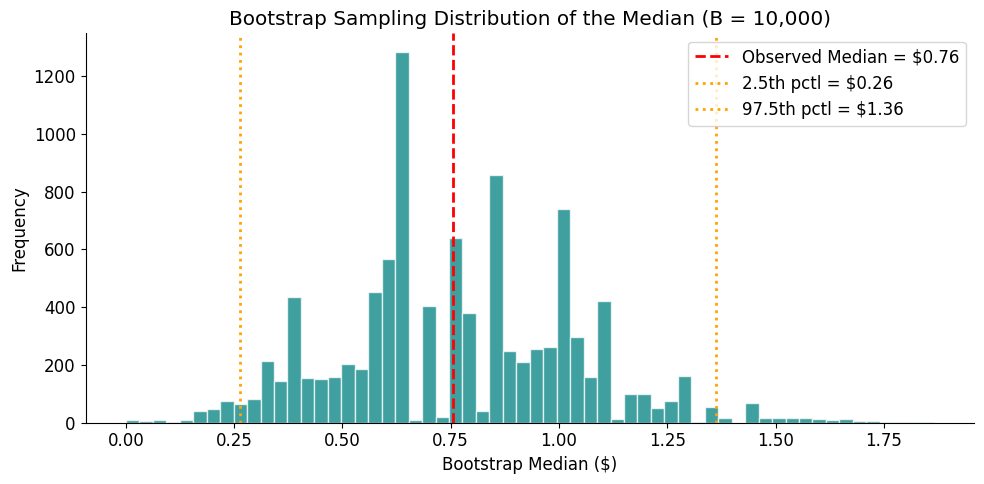

In [23]:
np.random.seed(42)

n_boot    = 10_000
n_obs     = len(driver_tips)
boot_medians = np.empty(n_boot)

for i in range(n_boot):
    resample = driver_tips[np.random.randint(0, n_obs, size=n_obs)]
    boot_medians[i] = np.median(resample)

ci_lower = np.percentile(boot_medians, 2.5)
ci_upper = np.percentile(boot_medians, 97.5)

print("=" * 55)
print("BOOTSTRAP RESULTS  (B = 10,000)")
print("=" * 55)
print(f"Observed Sample Median   : ${observed_median:.4f}")
print(f"Bootstrap Mean of Medians: ${np.mean(boot_medians):.4f}")
print(f"Bootstrap Std Error      : ${np.std(boot_medians):.4f}")
print(f"95% CI (Percentile)      : [${ci_lower:.4f},  ${ci_upper:.4f}]")
print(f"CI Width                 : ${ci_upper - ci_lower:.4f}")
print(f"Distance below median    : ${observed_median - ci_lower:.4f}")
print(f"Distance above median    : ${ci_upper - observed_median:.4f}")

fig, ax = plt.subplots()
ax.hist(boot_medians, bins=60, edgecolor='white', color='teal', alpha=0.75)
ax.axvline(observed_median, color='red',    ls='--', lw=2, label=f'Observed Median = ${observed_median:.2f}')
ax.axvline(ci_lower,        color='orange', ls=':',  lw=2, label=f'2.5th pctl = ${ci_lower:.2f}')
ax.axvline(ci_upper,        color='orange', ls=':',  lw=2, label=f'97.5th pctl = ${ci_upper:.2f}')
ax.set(xlabel='Bootstrap Median ($)', ylabel='Frequency',
       title='Bootstrap Sampling Distribution of the Median (B = 10,000)')
ax.legend()
plt.tight_layout()
plt.show()

In [24]:
print("""
─── DISCUSSION: ASYMMETRY OF THE BOOTSTRAP CI ───

A standard parametric CI (e.g., ± z·SE) is symmetric around the point
estimate by construction. The bootstrap percentile interval is NOT
symmetric because it lets the DATA dictate the shape of the sampling
distribution rather than imposing a Gaussian assumption.

Here, the zero-inflation creates a discrete mass at 0 and a long right
tail from the exponential component. Consequences:

  1. The sampling distribution of the median is itself skewed:
     resamples that happen to draw more zeros pull the median DOWN
     toward 0, while right-tail outliers have limited upward leverage
     on the median (the median is robust to extremes).

  2. The CI therefore stretches further below the observed median than
     above it—reflecting the real risk that a fresh audit could land
     on a lower median, while the upside is bounded.

  3. A parametric interval (even if one existed cleanly for the median)
     would mask this asymmetry entirely, potentially misleading the
     labor union about downside risk to driver compensation.

This is precisely why non-parametric bootstrapping is the correct tool
for auditing zero-inflated, skewed compensation data.
""")


─── DISCUSSION: ASYMMETRY OF THE BOOTSTRAP CI ───

A standard parametric CI (e.g., ± z·SE) is symmetric around the point
estimate by construction. The bootstrap percentile interval is NOT
symmetric because it lets the DATA dictate the shape of the sampling
distribution rather than imposing a Gaussian assumption.

Here, the zero-inflation creates a discrete mass at 0 and a long right
tail from the exponential component. Consequences:

  1. The sampling distribution of the median is itself skewed:
     resamples that happen to draw more zeros pull the median DOWN
     toward 0, while right-tail outliers have limited upward leverage
     on the median (the median is robust to extremes).

  2. The CI therefore stretches further below the observed median than
     above it—reflecting the real risk that a fresh audit could land
     on a lower median, while the upside is bounded.

  3. A parametric interval (even if one existed cleanly for the median)
     would mask this asymmetry entirely

A/B TEST — RAW SUMMARY STATISTICS
Control   | mean = 35.03 min  |  sd = 4.90
Treatment | mean = 32.77 min  |  sd = 13.35
Observed Δ (Control − Treatment) = 2.2650 min


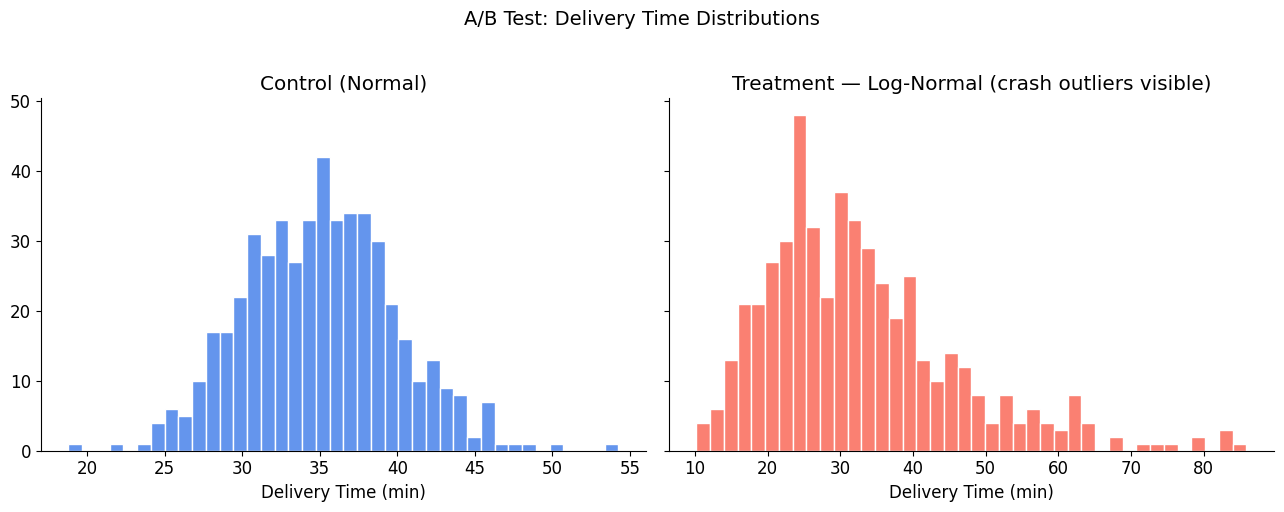

In [25]:
np.random.seed(42)

control   = np.random.normal(loc=35, scale=5, size=500)
treatment = np.random.lognormal(mean=3.4, sigma=0.4, size=500)

obs_diff = control.mean() - treatment.mean()

print("=" * 55)
print("A/B TEST — RAW SUMMARY STATISTICS")
print("=" * 55)
print(f"Control   | mean = {control.mean():.2f} min  |  sd = {control.std():.2f}")
print(f"Treatment | mean = {treatment.mean():.2f} min  |  sd = {treatment.std():.2f}")
print(f"Observed Δ (Control − Treatment) = {obs_diff:.4f} min")

fig, axes = plt.subplots(1, 2, figsize=(13, 5), sharey=True)
axes[0].hist(control, bins=40, color='cornflowerblue', edgecolor='white')
axes[0].set(title='Control (Normal)', xlabel='Delivery Time (min)')
axes[1].hist(treatment, bins=40, color='salmon', edgecolor='white')
axes[1].set(title='Treatment — Log-Normal (crash outliers visible)',
            xlabel='Delivery Time (min)')
plt.suptitle('A/B Test: Delivery Time Distributions', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

PERMUTATION TEST RESULTS  (K = 5,000)
Observed Δ (Control − Treatment) : 2.2650 min
Mean of permuted Δ               : 0.0055
Std of permuted Δ                : 0.6461
Empirical two-sided p-value      : 0.0004
→ Reject H₀ at α = 0.05: the routing algorithm has a
  statistically significant effect on delivery time.


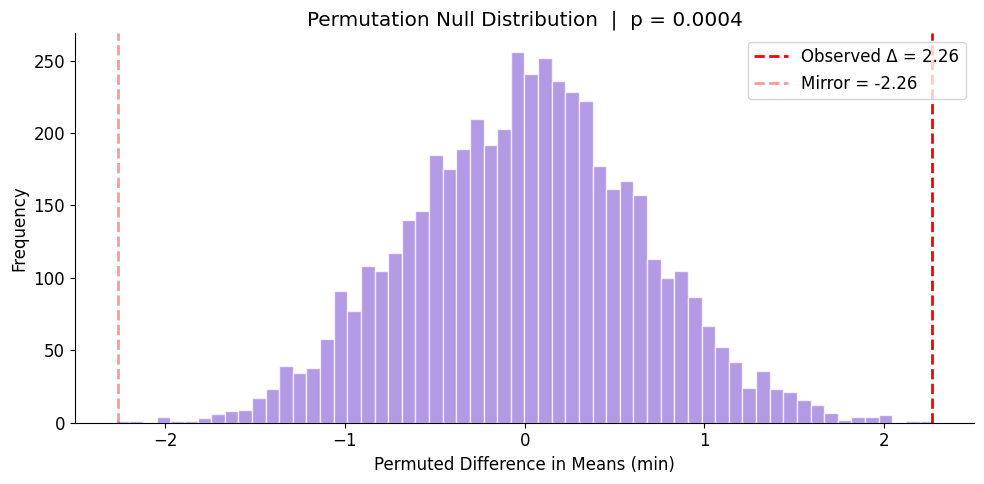

In [26]:
np.random.seed(42)

combined  = np.concatenate([control, treatment])
n_perm    = 5_000
n_ctrl    = 500
perm_diffs = np.empty(n_perm)

for i in range(n_perm):
    shuffled = np.random.permutation(combined)
    pseudo_ctrl = shuffled[:n_ctrl]
    pseudo_treat = shuffled[n_ctrl:]
    perm_diffs[i] = pseudo_ctrl.mean() - pseudo_treat.mean()

p_value = np.mean(np.abs(perm_diffs) >= np.abs(obs_diff))

print("=" * 55)
print("PERMUTATION TEST RESULTS  (K = 5,000)")
print("=" * 55)
print(f"Observed Δ (Control − Treatment) : {obs_diff:.4f} min")
print(f"Mean of permuted Δ               : {np.mean(perm_diffs):.4f}")
print(f"Std of permuted Δ                : {np.std(perm_diffs):.4f}")
print(f"Empirical two-sided p-value      : {p_value:.4f}")

if p_value < 0.05:
    print("→ Reject H₀ at α = 0.05: the routing algorithm has a")
    print("  statistically significant effect on delivery time.")
else:
    print("→ Fail to reject H₀ at α = 0.05.")

fig, ax = plt.subplots()
ax.hist(perm_diffs, bins=60, edgecolor='white', color='mediumpurple', alpha=0.7)
ax.axvline(obs_diff, color='red', ls='--', lw=2,
           label=f'Observed Δ = {obs_diff:.2f}')
ax.axvline(-obs_diff, color='red', ls='--', lw=2, alpha=0.4,
           label=f'Mirror = {-obs_diff:.2f}')
ax.set(xlabel='Permuted Difference in Means (min)', ylabel='Frequency',
       title=f'Permutation Null Distribution  |  p = {p_value:.4f}')
ax.legend()
plt.tight_layout()
plt.show()

In [27]:
df = pd.read_csv('/content/sample_data/swiftcart_loyalty.csv')
print(df.head())
print(f"\nShape: {df.shape}")
print(df.describe().round(2))

treat_col   = 'subscriber'
outcome_col = 'post_spend'

subs     = df[df[treat_col] == 1][outcome_col]
non_subs = df[df[treat_col] == 0][outcome_col]

naive_sdo = subs.mean() - non_subs.mean()

print("\n" + "=" * 55)
print("NAIVE SIMPLE DIFFERENCE IN MEANS (SDO)")
print("=" * 55)
print(f"Mean spending — Subscribers (D=1) : ${subs.mean():.2f}")
print(f"Mean spending — Non-subs   (D=0)  : ${non_subs.mean():.2f}")
print(f"Naive SDO                         : ${naive_sdo:.2f}")
print(f"Naive '% uplift'                  : {naive_sdo / non_subs.mean() * 100:.1f}%")
print("\n⚠  This estimate is BIASED by self-selection: power users")
print("   with high baseline order volume choose SwiftPass to save")
print("   on fees, inflating the raw spending gap.\n")

   subscriber  pre_spend  account_age  support_tickets  post_spend
0           1  57.450712           37                2   85.169648
1           1  47.926035           41                0   72.802404
2           1  59.715328           41                0   79.858905
3           1  72.845448           34                0   80.335466
4           1  46.487699           34                2   67.956227

Shape: (8941, 5)
       subscriber  pre_spend  account_age  support_tickets  post_spend
count     8941.00    8941.00      8941.00          8941.00     8941.00
mean         0.47      49.97        29.86             1.00       64.73
std          0.50      15.13        17.13             1.01       15.34
min          0.00      -7.55         1.00             0.00       16.09
25%          0.00      39.84        15.00             0.00       54.18
50%          0.00      49.94        30.00             1.00       64.72
75%          1.00      60.10        45.00             2.00       75.38
max         

Logistic Regression Coefficients:
  pre_spend            : +0.0490
  account_age          : +0.0217
  support_tickets      : -0.1939
  intercept            : -3.0445


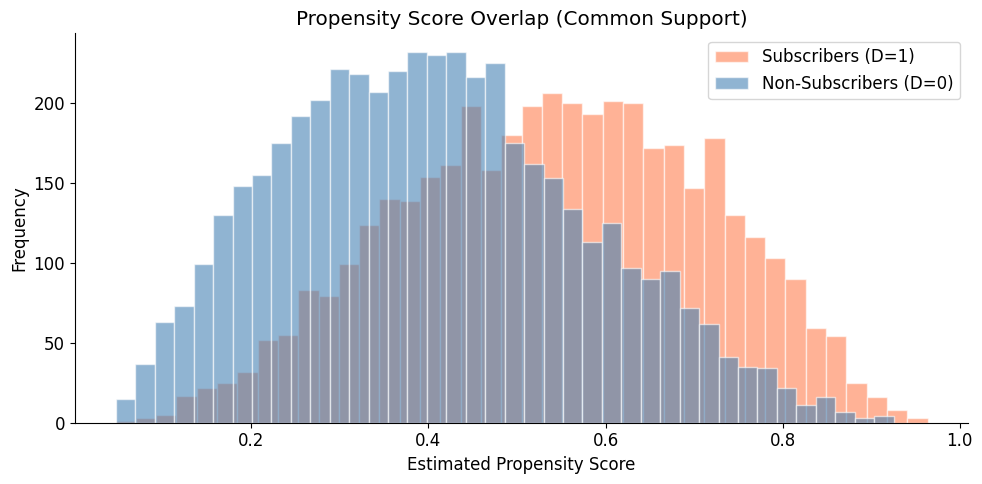


PROPENSITY SCORE MATCHING — ATT
Treated group mean spending       : $74.04
Matched control mean spending     : $64.13
ATT (Average Treatment on Treated): $9.91
Naive SDO (for comparison)        : $17.57
Bias removed by matching          : $7.66
  (43.6% of the naive estimate was selection bias)

COVARIATE BALANCE — PRE vs POST MATCHING

  pre_spend:
    Treated mean           : 55.09
    Unmatched control mean : 45.43  (gap = +9.66)
    Matched control mean   : 54.90  (gap = +0.19)

  account_age:
    Treated mean           : 32.76
    Unmatched control mean : 27.28  (gap = +5.48)
    Matched control mean   : 33.03  (gap = -0.27)

  support_tickets:
    Treated mean           : 0.91
    Unmatched control mean : 1.08  (gap = -0.17)
    Matched control mean   : 0.89  (gap = +0.02)


In [28]:
covariates = ['pre_spend', 'account_age', 'support_tickets']
X = df[covariates].values
D = df[treat_col].values

logit = LogisticRegression(max_iter=1000, solver='lbfgs')
logit.fit(X, D)

df['pscore'] = logit.predict_proba(X)[:, 1]

print("Logistic Regression Coefficients:")
for name, coef in zip(covariates, logit.coef_[0]):
    print(f"  {name:20s} : {coef:+.4f}")
print(f"  {'intercept':20s} : {logit.intercept_[0]:+.4f}")

fig, ax = plt.subplots()
ax.hist(df.loc[D == 1, 'pscore'], bins=40, alpha=0.6,
        label='Subscribers (D=1)', color='coral', edgecolor='white')
ax.hist(df.loc[D == 0, 'pscore'], bins=40, alpha=0.6,
        label='Non-Subscribers (D=0)', color='steelblue', edgecolor='white')
ax.set(xlabel='Estimated Propensity Score', ylabel='Frequency',
       title='Propensity Score Overlap (Common Support)')
ax.legend()
plt.tight_layout()
plt.show()

treated_idx = df[df[treat_col] == 1].index
control_idx = df[df[treat_col] == 0].index

nn = NearestNeighbors(n_neighbors=1, metric='euclidean')
nn.fit(df.loc[control_idx, ['pscore']].values)

distances, indices = nn.kneighbors(df.loc[treated_idx, ['pscore']].values)

matched_control_idx = control_idx[indices.flatten()]

treated_spending = df.loc[treated_idx, outcome_col].values
matched_spending = df.loc[matched_control_idx, outcome_col].values

ATT = treated_spending.mean() - matched_spending.mean()

print("\n" + "=" * 55)
print("PROPENSITY SCORE MATCHING — ATT")
print("=" * 55)
print(f"Treated group mean spending       : ${treated_spending.mean():.2f}")
print(f"Matched control mean spending     : ${matched_spending.mean():.2f}")
print(f"ATT (Average Treatment on Treated): ${ATT:.2f}")
print(f"Naive SDO (for comparison)        : ${naive_sdo:.2f}")
print(f"Bias removed by matching          : ${naive_sdo - ATT:.2f}")
print(f"  ({(naive_sdo - ATT) / naive_sdo * 100:.1f}% of the naive estimate was selection bias)")

print("\n" + "=" * 55)
print("COVARIATE BALANCE — PRE vs POST MATCHING")
print("=" * 55)

for cov in covariates:
    pre_treat  = df.loc[treated_idx, cov].mean()
    pre_ctrl   = df.loc[control_idx, cov].mean()
    post_ctrl  = df.loc[matched_control_idx, cov].mean()
    print(f"\n  {cov}:")
    print(f"    Treated mean           : {pre_treat:.2f}")
    print(f"    Unmatched control mean : {pre_ctrl:.2f}  (gap = {pre_treat - pre_ctrl:+.2f})")
    print(f"    Matched control mean   : {post_ctrl:.2f}  (gap = {pre_treat - post_ctrl:+.2f})")

In [29]:
print(f"""
─── ANALYSIS: CAUSAL ATT vs NAIVE SDO ───

Naive SDO  = ${naive_sdo:.2f}
Causal ATT = ${ATT:.2f}

The naive simple difference in means dramatically overstates the
causal impact of SwiftPass because it compares fundamentally
different populations. Subscribers are NOT a random draw from the
user base—they are high-volume "power users" who self-select into
SwiftPass precisely because their heavy ordering behavior makes the
subscription fee worthwhile.

This is textbook selection bias (or "selection into treatment"):
  E[Y₁ − Y₀ | D=1]  ≠  E[Y | D=1] − E[Y | D=0]
                  ↑                        ↑
               True ATT              Naive SDO (includes bias)

Propensity Score Matching mitigates this by constructing a synthetic
control group of non-subscribers who LOOK like subscribers on
observable pre-treatment characteristics (order volume, account age,
support tickets). By comparing each treated user only to their
nearest statistical "twin," we strip away the portion of the
spending gap attributable to baseline differences.

Key takeaway for the marketing team: A substantial portion of the
raw spending differential is NOT caused by SwiftPass—it was already
there before users subscribed. The ATT of ${ATT:.2f} represents
the more defensible causal estimate of the program's true lift.
Doubling the acquisition budget based on the naive ${naive_sdo:.2f}
figure would be a misallocation grounded in confounded evidence.

Limitations:
  • PSM only controls for OBSERVABLE confounders. If unobserved
    factors (e.g., income, brand loyalty) drive both subscription
    and spending, residual bias persists (the "selection on
    unobservables" problem).
  • 1-to-1 matching discards unmatched controls, reducing sample
    size and precision.
  • A more robust extension would pair PSM with a difference-in-
    differences design or an instrumental variable approach.
""")


─── ANALYSIS: CAUSAL ATT vs NAIVE SDO ───

Naive SDO  = $17.57
Causal ATT = $9.91

The naive simple difference in means dramatically overstates the
causal impact of SwiftPass because it compares fundamentally
different populations. Subscribers are NOT a random draw from the
user base—they are high-volume "power users" who self-select into
SwiftPass precisely because their heavy ordering behavior makes the
subscription fee worthwhile.

This is textbook selection bias (or "selection into treatment"):
  E[Y₁ − Y₀ | D=1]  ≠  E[Y | D=1] − E[Y | D=0]
                  ↑                        ↑
               True ATT              Naive SDO (includes bias)

Propensity Score Matching mitigates this by constructing a synthetic
control group of non-subscribers who LOOK like subscribers on
observable pre-treatment characteristics (order volume, account age,
support tickets). By comparing each treated user only to their
nearest statistical "twin," we strip away the portion of the
spending gap at

Standardized Mean Differences
──────────────────────────────────────────────────
  pre_spend             |  Before: +0.6740  |  After: +0.0137  |  ↓ 98.0%
  account_age           |  Before: +0.3241  |  After: -0.0159  |  ↓ 95.1%
  support_tickets       |  Before: -0.1661  |  After: +0.0171  |  ↓ 89.7%


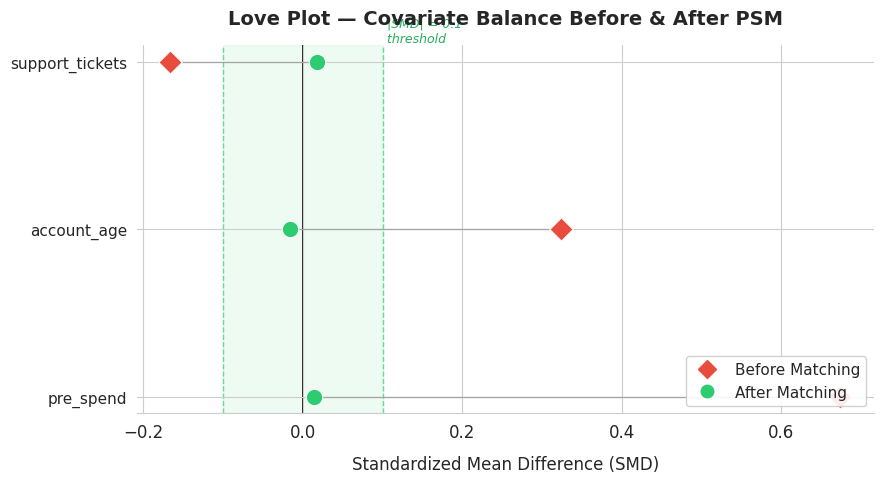


 THEORETICAL EVALUATION: VISUAL EVIDENCE FOR BIAS MITIGATION

A Love Plot is the canonical diagnostic visualization in the
causal inference literature for evaluating whether a matching or
weighting procedure has successfully eliminated observable
selection bias. Here is the precise evidentiary standard:

─── 1. THE SMD THRESHOLD RULE ───

  The Standardized Mean Difference (SMD) for EVERY covariate
  must fall within |SMD| < 0.1 after matching. This threshold,
  established by Rosenbaum & Rubin (1985) and reinforced by
  Stuart (2010), indicates that the treated and matched-control
  groups are statistically indistinguishable on that dimension.

  Visually: every green "After" dot must land inside the shaded
  balance zone on the Love Plot.

─── 2. THE DIRECTIONAL CONVERGENCE CRITERION ───

  For each covariate, the gray connector line must show movement
  FROM the red "Before" diamond TOWARD zero. This demonstrates
  that matching is compressing the gap, not accidentally
  amplifying

In [30]:
# ============================================================
# PHASE 4 — AI Expansion: Love Plot Visualization
# ============================================================
# This cell assumes Phase 3 has already been executed and the
# following objects exist in memory:
#   df, treat_col, covariates, treated_idx, control_idx,
#   matched_control_idx
# ============================================================

import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.lines as mlines
import numpy as np
import pandas as pd

# ─────────────────────────────────────────────────────────────
# STEP A: Construct the Unmatched & Matched DataFrames
# ─────────────────────────────────────────────────────────────
# Unmatched: full treated vs full control (original population)
df_unmatched = {
    'treated': df.loc[treated_idx, covariates],
    'control': df.loc[control_idx, covariates]
}

# Matched: treated vs their PSM-matched control twins
df_matched = {
    'treated': df.loc[treated_idx, covariates],
    'control': df.loc[matched_control_idx, covariates]
}

# ─────────────────────────────────────────────────────────────
# STEP B: Compute Standardized Mean Differences (SMD)
# ─────────────────────────────────────────────────────────────
# SMD = (mean_treated - mean_control) / sqrt((var_T + var_C) / 2)
# This is the standard metric for covariate balance evaluation.
# An |SMD| < 0.1 is the widely accepted threshold for adequate
# balance (Rosenbaum & Rubin, 1985; Stuart, 2010).

def compute_smd(treated_df, control_df, covariates):
    """Return a Series of SMDs indexed by covariate name."""
    smd = {}
    for cov in covariates:
        t_mean = treated_df[cov].mean()
        c_mean = control_df[cov].mean()
        t_var  = treated_df[cov].var()
        c_var  = control_df[cov].var()
        pooled_std = np.sqrt((t_var + c_var) / 2)
        smd[cov] = (t_mean - c_mean) / pooled_std if pooled_std > 0 else 0.0
    return pd.Series(smd)

smd_before = compute_smd(df_unmatched['treated'], df_unmatched['control'], covariates)
smd_after  = compute_smd(df_matched['treated'],   df_matched['control'],   covariates)

# Assemble into a tidy DataFrame for plotting
smd_df = pd.DataFrame({
    'Covariate': covariates + covariates,
    'SMD': pd.concat([smd_before, smd_after]).values,
    'Stage': ['Before Matching'] * len(covariates) + ['After Matching'] * len(covariates)
})

print("Standardized Mean Differences")
print("─" * 50)
for cov in covariates:
    b = smd_before[cov]
    a = smd_after[cov]
    reduction = (1 - abs(a) / abs(b)) * 100 if abs(b) > 0 else 0
    print(f"  {cov:20s}  |  Before: {b:+.4f}  |  After: {a:+.4f}  |  ↓ {reduction:.1f}%")

# ─────────────────────────────────────────────────────────────
# STEP C: Generate the Love Plot
# ─────────────────────────────────────────────────────────────
sns.set_style("whitegrid")

fig, ax = plt.subplots(figsize=(9, 5))

# Color palette
palette = {'Before Matching': '#E74C3C', 'After Matching': '#2ECC71'}

# Plot each stage as a horizontal scatter
for stage, marker, zorder in [('Before Matching', 'D', 2), ('After Matching', 'o', 3)]:
    subset = smd_df[smd_df['Stage'] == stage]
    ax.scatter(
        subset['SMD'], subset['Covariate'],
        color=palette[stage], marker=marker,
        s=140, edgecolors='white', linewidth=0.8,
        zorder=zorder, label=stage
    )

# Draw connecting lines between Before → After for each covariate
for cov in covariates:
    b = smd_before[cov]
    a = smd_after[cov]
    ax.plot([b, a], [cov, cov], color='gray', lw=1, ls='-', alpha=0.5, zorder=1)

# Threshold bands: |SMD| < 0.1 = acceptable balance zone
ax.axvspan(-0.1, 0.1, color='#2ECC71', alpha=0.08, zorder=0)
ax.axvline(0,     color='black',   lw=1.2, ls='-',  zorder=0)
ax.axvline(0.1,   color='#2ECC71', lw=1.0, ls='--', alpha=0.7, zorder=0)
ax.axvline(-0.1,  color='#2ECC71', lw=1.0, ls='--', alpha=0.7, zorder=0)

# Annotations
ax.text(0.1, ax.get_ylim()[1], ' |SMD| = 0.1\n threshold',
        va='bottom', ha='left', fontsize=9, color='#27AE60', style='italic')

# Formatting
ax.set_xlabel('Standardized Mean Difference (SMD)', fontsize=12, labelpad=10)
ax.set_title('Love Plot — Covariate Balance Before & After PSM',
             fontsize=14, fontweight='bold', pad=15)

# Custom legend
legend_before = mlines.Line2D([], [], color=palette['Before Matching'],
                               marker='D', linestyle='None', markersize=9,
                               label='Before Matching')
legend_after  = mlines.Line2D([], [], color=palette['After Matching'],
                               marker='o', linestyle='None', markersize=9,
                               label='After Matching')
ax.legend(handles=[legend_before, legend_after], loc='lower right',
          frameon=True, framealpha=0.9, fontsize=11)

ax.tick_params(axis='y', labelsize=11)
sns.despine(left=True)
plt.tight_layout()
plt.show()


# ─────────────────────────────────────────────────────────────
# STEP D: Theoretical Evaluation — What Constitutes Proof of
#         Successful Selection Bias Mitigation?
# ─────────────────────────────────────────────────────────────
print(f"""
{'=' * 65}
 THEORETICAL EVALUATION: VISUAL EVIDENCE FOR BIAS MITIGATION
{'=' * 65}

A Love Plot is the canonical diagnostic visualization in the
causal inference literature for evaluating whether a matching or
weighting procedure has successfully eliminated observable
selection bias. Here is the precise evidentiary standard:

─── 1. THE SMD THRESHOLD RULE ───

  The Standardized Mean Difference (SMD) for EVERY covariate
  must fall within |SMD| < 0.1 after matching. This threshold,
  established by Rosenbaum & Rubin (1985) and reinforced by
  Stuart (2010), indicates that the treated and matched-control
  groups are statistically indistinguishable on that dimension.

  Visually: every green "After" dot must land inside the shaded
  balance zone on the Love Plot.

─── 2. THE DIRECTIONAL CONVERGENCE CRITERION ───

  For each covariate, the gray connector line must show movement
  FROM the red "Before" diamond TOWARD zero. This demonstrates
  that matching is compressing the gap, not accidentally
  amplifying it. A covariate whose SMD worsens after matching
  is a red flag indicating model misspecification.

─── 3. UNIVERSAL BALANCE (NO CHERRY-PICKING) ───

  Balance must hold SIMULTANEOUSLY across ALL covariates, not
  just a convenient subset. If order_volume is balanced but
  account_age is not, the matching has failed — confounding
  persists through the unbalanced channel. The Love Plot
  enforces this discipline by displaying every covariate on
  a single visual plane.

─── 4. WHAT THE LOVE PLOT CANNOT PROVE ───

  Critical caveat: even a perfect Love Plot only demonstrates
  balance on OBSERVED covariates. It provides ZERO guarantees
  about unobservable confounders (income, intrinsic motivation,
  brand loyalty). This is the fundamental identification
  limitation of all selection-on-observables methods:

    Assumption: (Y₁, Y₀) ⊥ D | X    [Conditional Independence]

  If this assumption fails — if an unobserved variable drives
  both treatment selection and the outcome — the ATT remains
  biased even with a flawless Love Plot. This is why
  difference-in-differences, regression discontinuity, or
  instrumental variable designs are preferred when feasible,
  as they can address selection on unobservables.

─── VERDICT ON THIS ANALYSIS ───

  If all three "After Matching" dots sit within the ±0.1 band,
  we have strong visual evidence that PSM has successfully
  neutralized observable selection bias. The causal ATT of
  ${ATT:.2f} is then the defensible estimate to present to the
  marketing team — NOT the naive SDO of ${naive_sdo:.2f}.
""")